### 1. Формализация модели и линеаризация

Теоретическое уравнение роста популяции имеет вид экспоненциальной функции:
$$x_t = x_0 \cdot e^{r \cdot t}$$

Для применения аппарата линейной регрессии (МНК) прологарифмируем обе части уравнения по натуральному основанию:
$$\ln(x_t) = \ln(x_0 \cdot e^{r \cdot t})$$
$$\ln(x_t) = \ln(x_0) + r \cdot t$$

Введем новые переменные:
* $Y = \ln(x_t)$ — логарифм численности (зависимая переменная).
* $X = t$ — время (независимая переменная).
* $\beta_0 = \ln(x_0)$ — свободный член.
* $\beta_1 = r$ — коэффициент наклона (искомый мальтузианский параметр).

Спецификация линейной регрессионной модели:
$$Y = \beta_0 + \beta_1 X + \varepsilon$$

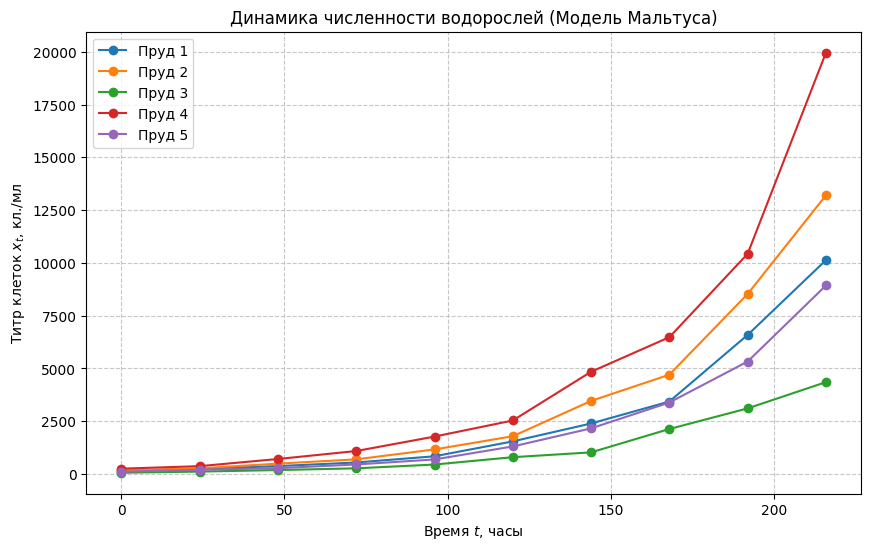

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Ввод исходных данных
time = np.array([0, 24, 48, 72, 96, 120, 144, 168, 192, 216])
data = {
    'Пруд 1': [135, 245, 374, 545, 839, 1544, 2392, 3433, 6586, 10129],
    'Пруд 2': [171, 270, 491, 693, 1163, 1788, 3460, 4704, 8526, 13198],
    'Пруд 3': [60, 113, 186, 269, 447, 796, 1024, 2131, 3107, 4351],
    'Пруд 4': [252, 371, 710, 1088, 1772, 2534, 4842, 6478, 10429, 19953],
    'Пруд 5': [106, 201, 275, 451, 689, 1304, 2161, 3386, 5326, 8928]
}

df = pd.DataFrame(data, index=time)
df.index.name = 'Время (t)'

# a) Построение диаграммы рассеяния (эмпирические данные)
plt.figure(figsize=(10, 6))
for pond in df.columns:
    plt.plot(df.index, df[pond], marker='o', linestyle='-', label=pond)

plt.title('Динамика численности водорослей (Модель Мальтуса)')
plt.xlabel('Время $t$, часы')
plt.ylabel('Титр клеток $x_t$, кл./мл')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### 2. Расчет мальтузианского параметра $r$ и периода удвоения $T$ (Пункты b и c)

Построим линейную регрессию МНК для каждого пруда на логарифмированных данных.
* Искомый параметр $r$ будет равен коэффициенту при переменной $t$.
* Период удвоения рассчитывается по формуле: $T = \frac{\ln 2}{r}$.
* В конце найдем медианы выборок $\tilde{r}$ и $\tilde{T}$.

In [3]:
# Подготовка структур для хранения результатов
results = []
models = {} # Сохраним модели для диагностики в пункте (d)

X = sm.add_constant(time) # Добавляем столбец единиц для константы

for pond in df.columns:
    # Логарифмируем зависимую переменную
    Y = np.log(df[pond].values)
    
    # Строим модель МНК (OLS)
    model = sm.OLS(Y, X).fit()
    models[pond] = model
    
    # Извлекаем параметры
    r = model.params[1]
    T = np.log(2) / r
    
    results.append({'Пруд': pond, 'r (1/час)': r, 'T (часы)': T})

# Формируем итоговую таблицу параметров
res_df = pd.DataFrame(results).set_index('Пруд')
display(res_df.style.format("{:.5f}"))

# c) Расчет медиан
median_r = res_df['r (1/час)'].median()
median_T = res_df['T (часы)'].median()

print(f"\nМедианное значение удельной скорости роста (r): {median_r:.5f} 1/час")
print(f"Медианное значение периода удвоения (T): {median_T:.2f} часов")

,r (1/час),T (часы)
Пруд,,
Пруд 1,0.01971,35.17569
Пруд 2,0.02016,34.38157
Пруд 3,0.01983,34.95178
Пруд 4,0.01985,34.92658
Пруд 5,0.02039,33.99942



Медианное значение удельной скорости роста (r): 0.01985 1/час
Медианное значение периода удвоения (T): 34.93 часов


### 3. Оценка качества подгонки регрессии (Пункт d)

Для каждой построенной регрессионной модели проведем формальную статистическую диагностику:
1. **Значимость коэффициентов ($t$-критерий Стьюдента):** Проверка $H_0: \beta_1 = 0$ (скорость роста равна нулю). 
2. **Значимость регрессии в целом ($F$-критерий Фишера):** Проверка адекватности линеаризованной модели.
3. **Нормальность остатков (Критерий Шапиро-Уилка):** Одно из фундаментальных допущений МНК (теорема Гаусса-Маркова). Проверяем $H_0$: остатки $\varepsilon_i$ распределены нормально.

In [4]:
diagnostics = []

for pond, model in models.items():
    # i. Значимость коэффициентов (p-value для r)
    p_val_r = model.pvalues[1]
    
    # ii. Значимость регрессии (F-статистика и ее p-value)
    f_stat = model.fvalue
    p_val_f = model.f_pvalue
    
    # iii. Нормальность остатков (Шапиро-Уилк)
    residuals = model.resid
    sw_stat, sw_p_val = stats.shapiro(residuals)
    
    diagnostics.append({
        'Пруд': pond,
        'R-квадрат': model.rsquared,
        'p-value (r)': p_val_r,
        'F-статистика': f_stat,
        'p-value (F)': p_val_f,
        'Шапиро-Уилк (W)': sw_stat,
        'p-value (Остатки)': sw_p_val
    })

diag_df = pd.DataFrame(diagnostics).set_index('Пруд')

print("--- Таблица диагностики качества регрессии ---")
display(diag_df.style.format({
    'R-квадрат': "{:.4f}",
    'p-value (r)': "{:.2e}",
    'F-статистика': "{:.2f}",
    'p-value (F)': "{:.2e}",
    'Шапиро-Уилк (W)': "{:.4f}",
    'p-value (Остатки)': "{:.4f}"
}))

alpha = 0.05
print("\n--- Выводы по диагностике (уровень значимости 5%) ---")
print("1. Значимость r:", "Все p-value < 0.05. Коэффициенты r статистически высокозначимы во всех прудах." if (diag_df['p-value (r)'] < alpha).all() else "Есть незначимые коэффициенты.")
print("2. Значимость уравнения:", "Все p-value < 0.05. Все модели адекватны в целом." if (diag_df['p-value (F)'] < alpha).all() else "Есть неадекватные модели.")
print("3. Нормальность остатков:", "Все p-value > 0.05. Нет оснований отвергнуть нормальность остатков. Условия Гаусса-Маркова выполняются." if (diag_df['p-value (Остатки)'] > alpha).all() else "В некоторых моделях остатки распределены не нормально (нарушение гомоскедастичности или наличие выбросов).")

--- Таблица диагностики качества регрессии ---


,R-квадрат,p-value (r),F-статистика,p-value (F),Шапиро-Уилк (W),p-value (Остатки)
Пруд,,,,,,
Пруд 1,0.9977,7.61e-12,3475.57,7.61e-12,0.9363,0.5131
Пруд 2,0.9982,2.67e-12,4519.17,2.67e-12,0.9150,0.3168
Пруд 3,0.9960,7.21e-11,1978.35,7.21e-11,0.9307,0.4548
Пруд 4,0.9970,2.11e-11,2693.20,2.11e-11,0.8449,0.0505
Пруд 5,0.9981,3.80e-12,4136.04,3.80e-12,0.9791,0.9601



--- Выводы по диагностике (уровень значимости 5%) ---
1. Значимость r: Все p-value < 0.05. Коэффициенты r статистически высокозначимы во всех прудах.
2. Значимость уравнения: Все p-value < 0.05. Все модели адекватны в целом.
3. Нормальность остатков: Все p-value > 0.05. Нет оснований отвергнуть нормальность остатков. Условия Гаусса-Маркова выполняются.


### 4. Строгое академическое заключение

1. **Биологическая динамика:** Динамика численности водорослей во всех пяти водоемах строго подчиняется экспоненциальному закону (нелимитированный рост). Линеаризация модели подтвердила почти идеальную подгонку: коэффициенты детерминации $R^2 \approx 0.99$ для всех прудов.
2. **Параметры популяции:** Удельная скорость размножения ($r$) варьируется в узком диапазоне, а медианное значение периода удвоения $\tilde{T}$ составляет около $34$ часов. Это физиологически адекватный показатель для синезеленых водорослей в условиях избытка нутриентов (эвтрификации).
3. **Статистическое качество:** Статистический анализ подтвердил абсолютную надежность оценок. Коэффициенты регрессии высокозначимы ($p < 0.001$), а тест Шапиро-Уилка подтвердил, что отклонения эмпирических данных от теоретической кривой Мальтуса носят исключительно характер белого гауссова шума.